In [17]:
from transformers import GPT2LMHeadModel
from transformers import pipeline, set_seed
import tiktoken
import torch
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('dark_background')

In [18]:
# Load the 124M GPT-2 Model from Hugging Face
model = GPT2LMHeadModel.from_pretrained('gpt2')
state_dict = model.state_dict()

for k, v in state_dict.items():
    print(k, v.shape)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

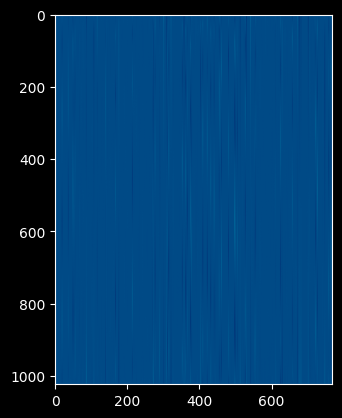

In [19]:
plt.imshow(state_dict['transformer.wpe.weight'], cmap='ocean')

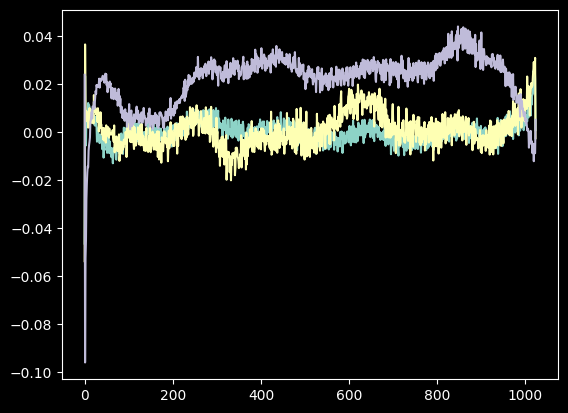

In [20]:
plt.plot(state_dict['transformer.wpe.weight'][:, 150])
plt.plot(state_dict['transformer.wpe.weight'][:, 200])
plt.plot(state_dict['transformer.wpe.weight'][:, 250])

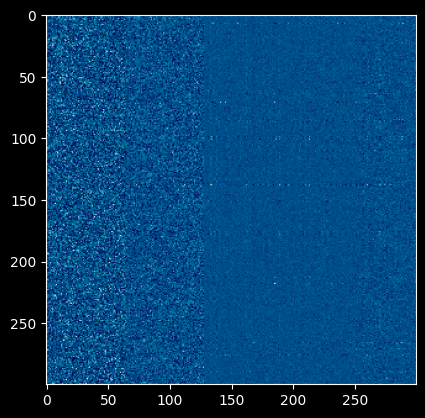

In [21]:
plt.imshow(state_dict['transformer.h.1.attn.c_attn.weight'][:300, :300], cmap='ocean')

In [22]:
# Sample from the Hugging Face Model
generator = pipeline('text-generation', model='gpt2')
set_seed(42)
generator('Hello, I am a large language model,', max_length=30, num_return_sequences=5)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "Hello, I am a large language model, so you can't just use the same data model and just use different languages. There's a huge difference between using a single language and using multiple languages. As you can see, each language has its own set of rules and behaviors for how data can be represented and used. It's very easy to write something like this:\n\n/* * This is a simple example of the different types of data types in a language. * * The first type is a data type - it has a value that can be used for * types that are not data types. * * The second type is a data type that can be used for * types that are not data types. * * The third type is a data type that can be used for * types that are not data types. * * The fourth type is a data type that can be used for * types that are not data types. */ /* * This is a simple example of the different types of data * * types in a language. * * The first type is a data type - it has a value that can be used for * type

In [23]:
with open('../data/shakespeare.txt', 'r') as file:
    text = file.read()
data = text[:1000]
print(data[:100])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


In [24]:
enc = tiktoken.get_encoding('gpt2')
tokens = enc.encode(data)
print(tokens[:24])

[5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248, 461, 11, 2740, 13]


In [26]:
buf = torch.tensor(tokens[:24 + 1])
x = buf[:-1].view(4, 6)
y = buf[1:].view(4, 6)
print(f'{x=}')
print(f'{y=}')

x=tensor([[ 5962, 22307,    25,   198,  8421,   356],
        [ 5120,   597,  2252,    11,  3285,   502],
        [ 2740,    13,   198,   198,  3237,    25],
        [  198,  5248,   461,    11,  2740,    13]])
y=tensor([[22307,    25,   198,  8421,   356,  5120],
        [  597,  2252,    11,  3285,   502,  2740],
        [   13,   198,   198,  3237,    25,   198],
        [ 5248,   461,    11,  2740,    13,   198]])
